In [ ]:
# 首先 import 一些主要的包
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.utils.data as Data


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


# 获取文件名
file_name = 'train_data.npy'

# 读取数组
data = np.load(file_name)


# 生成题目所需的训练集合
def generate_data(data):
    # 记录 data 的长度
    n = data.shape[0]

    # 目标是生成可直接用于训练和测试的 x 和 y
    x = []
    y = []

    # 建立 (14 -> 1) 的 x 和 y
    for i in range(15, n):
        x.append(data[i - 15: i - 1])
        y.append(data[i - 1])

    # 转换为 numpy 数组
    x = np.array(x)
    y = np.array(y)

    return x, y


x, y = generate_data(data)
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# 将 y 转化形状
y = torch.unsqueeze(y, dim=1)
print(x.shape, y.shape)

# 样本总数
num_samples = x.shape[0]
num_train = round(num_samples * 0.8)
num_valid = round(num_samples * 0.1)
num_test = num_samples - num_train - num_valid

dataset = Data.TensorDataset(x, y)
train_data, valid_data, test_data = Data.random_split(dataset, (num_train, num_valid, num_test))

batch_size = 512
train_loader = Data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = Data.DataLoader(valid_data, batch_size=batch_size, shuffle=False)
test_loader = Data.DataLoader(test_data, batch_size=batch_size, shuffle=False)


def compute_mae(y_hat, y):
    """
    :param y_hat: 用户的预测值
    :param y: 标准值
    :return: MAE 平均绝对误差 mean(|y*-y|)
    """
    return torch.mean(torch.abs(y_hat - y))


def compute_mape(y_hat, y):
    """
    :param y_hat: 用户的预测值
    :param y: 标准值
    :return: MAPE 平均百分比误差 mean(|y*-y|/y)
    """
    return torch.mean(torch.abs(y_hat - y)/y)


def evaluate_accuracy(data_loader, model):
    """
    :param data_loader: 输入的 DataLoader
    :param model: 用户的模型
    :return: 对应的 MAE 和 MAPE
    """
    # 初始化参数
    mae_sum, mape_sum, n = 0.0, 0.0, 0

    # 对每一个 data_iter 的每一个 x,y 进行计算
    for x, y in data_loader:
        x = x.to(device)
        # 计算模型得出的 y_hat
        y_hat = model(x)

        # 计算对应的 MAE 和 RMSE 对应的和，并乘以 batch 大小
        mae_sum += compute_mae(y_hat, y) * y.shape[0]
        mape_sum += compute_mape(y_hat, y) * y.shape[0]

        # n 用于统计 DataLoader 中一共有多少数量
        n += y.shape[0]

    # 返回时需要除以 batch 大小，得到平均值
    return mae_sum / n, mape_sum / n

torch.Size([1984, 14]) torch.Size([1984, 1])


In [ ]:
# 输入的数量是前 14 个交易日的收盘价
num_inputs = 14
# 输出是下一个交易日的收盘价
num_outputs = 1
# 隐藏层的个数（增加隐藏层大小）
num_hiddens = 256
# LSTM 层数
num_layers = 2
# Dropout 比率
dropout_rate = 0.2


# 优化的 LSTM 模型
class OptimizedLSTM(nn.Module):
    def __init__(self, num_hiddens, num_layers, num_outputs, dropout_rate=0.2):
        super(OptimizedLSTM, self).__init__()
        # 多层 LSTM，添加 dropout
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=num_hiddens,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Batch Normalization
        self.bn = nn.BatchNorm1d(num_hiddens)
        
        # 更深的全连接层
        self.fc1 = nn.Linear(num_hiddens, num_hiddens // 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(num_hiddens // 2, num_hiddens // 4)
        self.fc3 = nn.Linear(num_hiddens // 4, num_outputs)
        
        # 激活函数
        self.relu = nn.ReLU()
        
        # 权重初始化
        self._initialize_weights()
    
    def _initialize_weights(self):
        """初始化模型权重"""
        for name, param in self.named_parameters():
            if 'weight' in name:
                if len(param.shape) >= 2:
                    nn.init.xavier_uniform_(param)
                else:
                    nn.init.uniform_(param, -0.1, 0.1)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
    
    def forward(self, x):
        # 重塑输入: [batch_size, seq_len] -> [batch_size, seq_len, 1]
        x = x.view(x.shape[0], -1, 1)
        
        # LSTM 前向传播
        r_out, (h_n, h_c) = self.lstm(x, None)
        
        # 取最后一个时间步的输出
        out = r_out[:, -1, :]  # [batch_size, hidden_size]
        
        # Batch Normalization
        out = self.bn(out)
        
        # 全连接层
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.relu(self.fc2(out))
        out = self.dropout(out)
        out = self.fc3(out)
        
        return out


# 创建优化后的模型
lstm = OptimizedLSTM(num_hiddens, num_layers, num_outputs, dropout_rate).to(device)

# 使用 Huber Loss（对异常值更鲁棒）或 Smooth L1 Loss
loss_fn = nn.SmoothL1Loss()  # 比 MSE 对异常值更鲁棒

# 优化器：添加权重衰减（L2 正则化）
optimizer = torch.optim.Adam(lstm.parameters(), lr=1e-3, weight_decay=1e-5)

# 学习率调度器：当验证损失不再下降时降低学习率
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15, verbose=True, min_lr=1e-6
)

# 早停机制
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

early_stopping = EarlyStopping(patience=30, min_delta=0.0001)

# 打印模型信息
def count_parameters(model):
    """统计模型参数数量"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(lstm)
print(f'模型总参数数量: {total_params:,}')
print(f'模型结构:')
print(lstm)


# 用于绘图用的信息
train_losses, valid_losses, train_maes, train_mapes, valid_maes, valid_mapes = [], [], [], [], [], []

# 记录最佳模型
best_valid_loss = float('inf')
best_model_state = None

# 循环 num_epochs 次
epochs = 300
for epoch in range(epochs):
    # 初始化参数
    train_l_sum, n = 0.0, 0
    # 初始化时间
    start = time.time()

    lstm.train()

    # 对训练数据集的每个 batch 执行
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        y_hat = lstm(x)
        loss = loss_fn(y_hat, y)
        
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪：防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(lstm.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_l_sum += loss.item() * y.shape[0]

        # 计数一共有多少个元素
        n += y.shape[0]

    # 模型开启预测状态
    lstm.eval()

    # 同样的，我们可以计算验证集上的 loss
    valid_l_sum, valid_n = 0, 0
    with torch.no_grad():  # 验证时不需要计算梯度
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            y_hat = lstm(x)
            loss = loss_fn(y_hat, y)

            # 对 loss 求和（在下面打印出来）
            valid_l_sum += loss.item() * y.shape[0]

            # 计数一共有多少个元素
            valid_n += y.shape[0]

    # 计算平均损失
    avg_train_loss = train_l_sum / n
    avg_valid_loss = valid_l_sum / valid_n
    
    # 学习率调度
    scheduler.step(avg_valid_loss)
    
    # 对验证集合求指标
    train_mae, train_mape = evaluate_accuracy(train_loader, lstm)
    valid_mae, valid_mape = evaluate_accuracy(valid_loader, lstm)
    
    # 记录最佳模型
    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        best_model_state = lstm.state_dict().copy()
    
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            'epoch %d, train loss %.6f, valid loss %.6f, train mae %.6f, mape %.6f, valid mae %.6f, mape %.6f, lr %.2e, time %.2f sec'
            % (epoch + 1, avg_train_loss, avg_valid_loss, train_mae, train_mape, valid_mae, valid_mape, current_lr,
               time.time() - start))

    # 记录绘图有关的信息
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    train_maes.append(train_mae)
    train_mapes.append(train_mape)
    valid_maes.append(valid_mae)
    valid_mapes.append(valid_mape)
    
    # 早停检查
    if early_stopping(avg_valid_loss):
        print(f'\n早停触发于 epoch {epoch + 1}')
        print(f'最佳验证损失: {best_valid_loss:.6f}')
        break

# 加载最佳模型
if best_model_state is not None:
    lstm.load_state_dict(best_model_state)
    print(f'\n已加载最佳模型（验证损失: {best_valid_loss:.6f}）')

epoch 10, train loss 51.944493, valid loss 51.852348, train mae 5.827519, mape 0.695481, valid mae 5.827520,mape 0.695481, time 0.36 sec
epoch 20, train loss 46.300249, valid loss 45.223255, train mae 5.163633, mape 0.585530, valid mae 5.163633,mape 0.585530, time 0.24 sec
epoch 30, train loss 17.703802, valid loss 15.526913, train mae 2.358863, mape 0.252493, valid mae 2.358863,mape 0.252493, time 0.63 sec
epoch 40, train loss 4.392334, valid loss 4.086491, train mae 0.816973, mape 0.048187, valid mae 0.816973,mape 0.048187, time 0.28 sec
epoch 50, train loss 2.161819, valid loss 2.051256, train mae 0.633546, mape 0.046207, valid mae 0.633546,mape 0.046207, time 0.27 sec
epoch 60, train loss 1.300399, valid loss 1.292236, train mae 0.544018, mape 0.040324, valid mae 0.544018,mape 0.040324, time 0.29 sec
epoch 70, train loss 0.954550, valid loss 0.966482, train mae 0.492144, mape 0.041353, valid mae 0.492144,mape 0.041353, time 0.31 sec
epoch 80, train loss 0.745629, valid loss 0.71948

: 

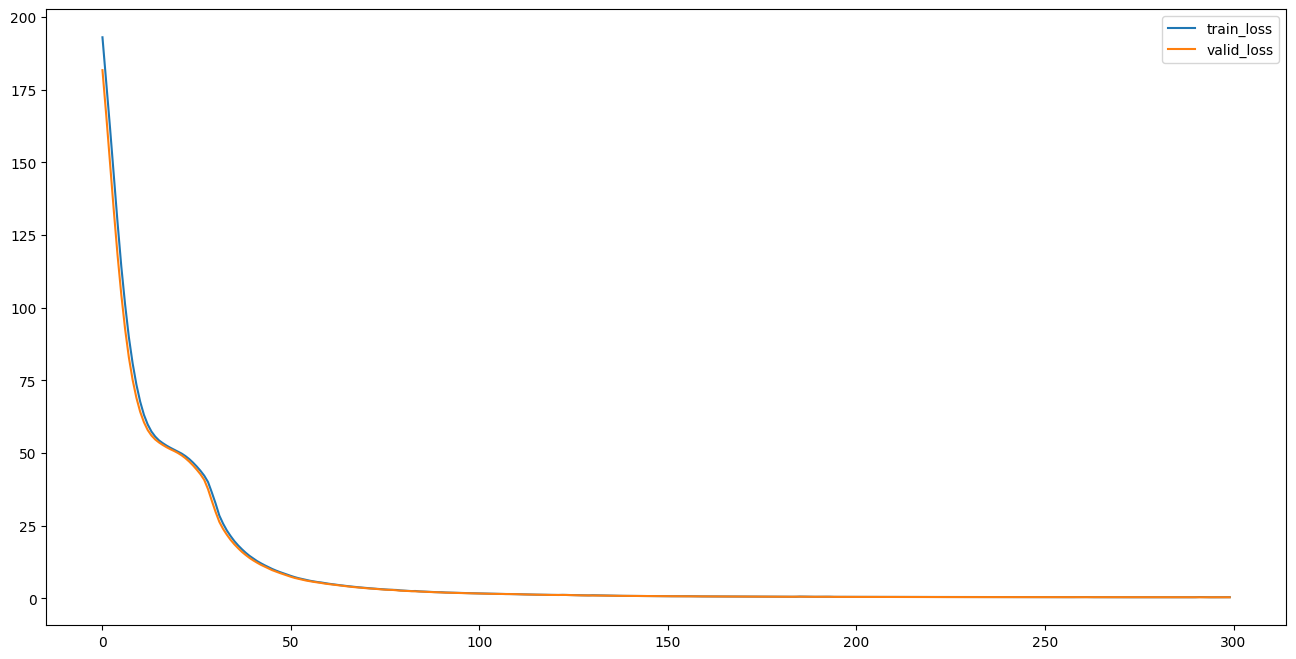

In [4]:
# 新建一个图像
plt.figure(figsize=(16,8))

# 绘制 train_loss 曲线
plt.plot(train_losses, label='train_loss')

# 绘制 valid_loss 曲线
plt.plot(valid_losses, label='valid_loss')

# 展示带标签的图像
plt.legend()

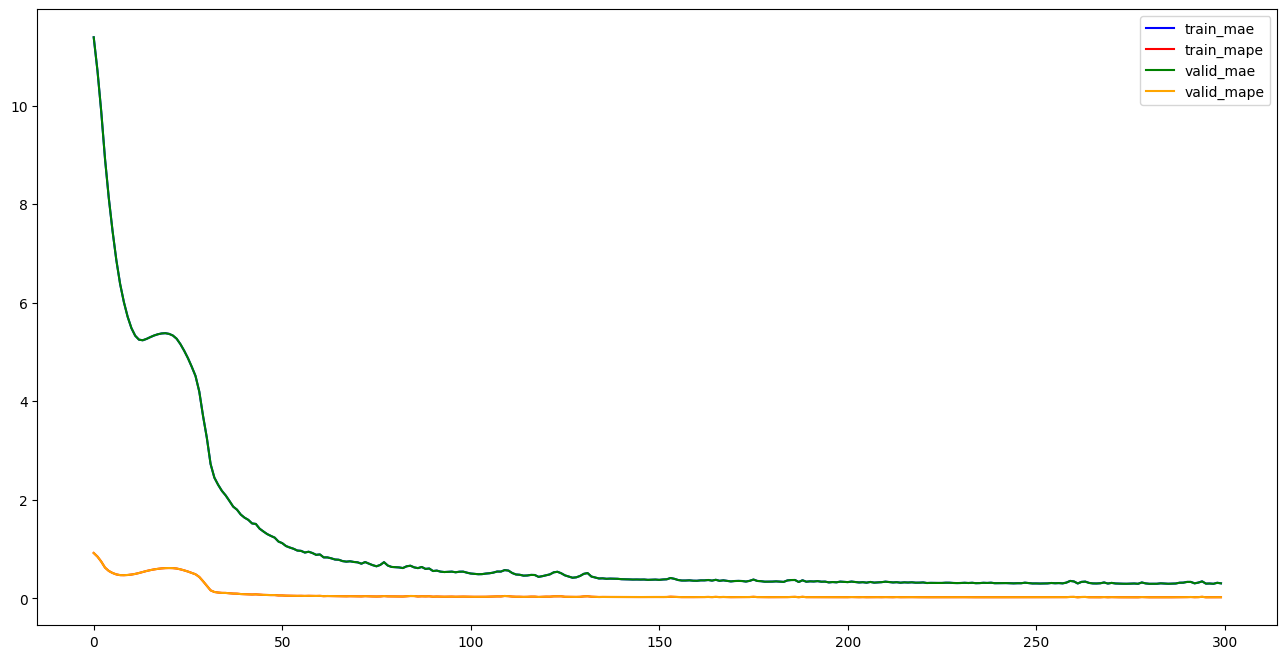

In [ ]:
# 新建一个图像
plt.figure(figsize=(16,8))

# 辅助函数：确保所有待绘制张量都被转换为numpy数组（兼容 list、numpy、torch）
import numpy as np

def to_numpy(arr):
    # 如果是Tensor列表，递归处理
    if isinstance(arr, list):
        return np.array([to_numpy(item) for item in arr])
    # 如果是PyTorch张量，转为numpy
    if hasattr(arr, 'detach') and callable(arr.detach):
        return arr.detach().cpu().numpy()
    if hasattr(arr, 'cpu') and callable(arr.cpu):
        return arr.cpu().numpy()
    # 如果已经是numpy数组或者标量，直接返回
    return np.array(arr)

# 绘画结点
plt.plot(to_numpy(train_maes), c='blue', label='train_mae')
plt.plot(to_numpy(train_mapes), c='red', label='train_mape')
plt.plot(to_numpy(valid_maes), c='green', label='valid_mae')
plt.plot(to_numpy(valid_mapes), c='orange', label='valid_mape')

# 展示图像
plt.legend()

In [ ]:
# 在测试集上评估最终模型性能
lstm.eval()
test_mae, test_mape = evaluate_accuracy(test_loader, lstm)
print(f'\n测试集性能:')
print(f'测试集 MAE: {test_mae:.6f}')
print(f'测试集 MAPE: {test_mape:.6f}')


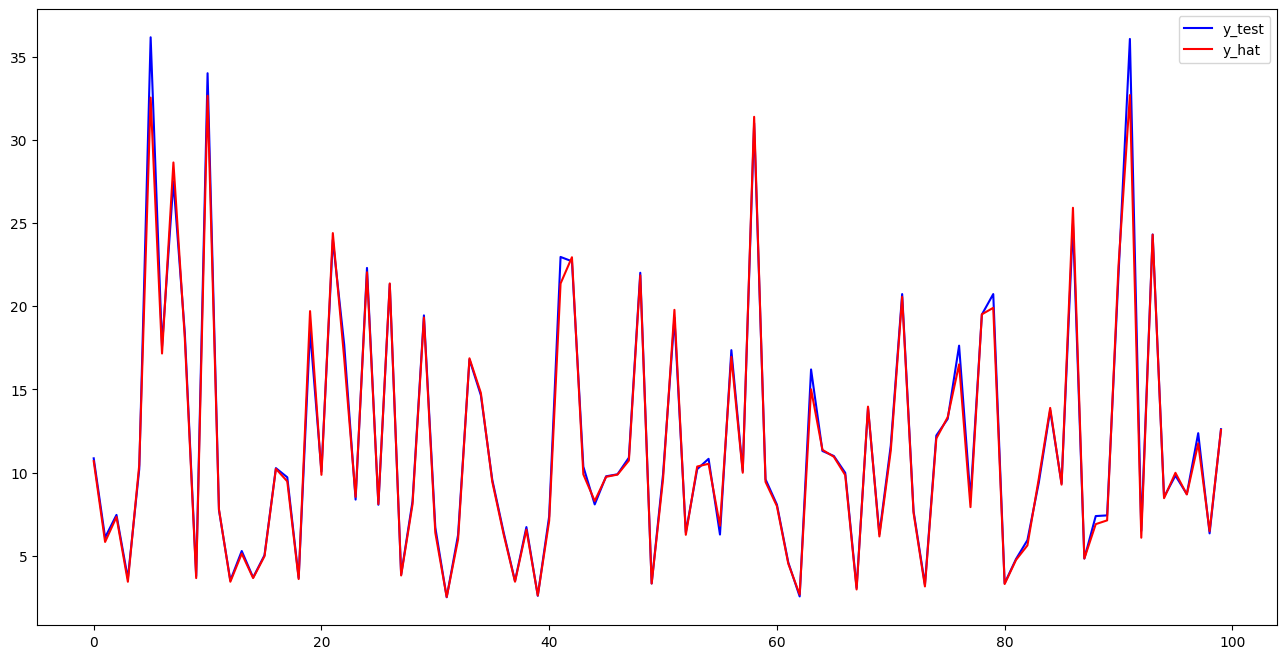

In [12]:
# 新建一个图像
plt.figure(figsize=(16,8))

# 预测结果
x_test, y_test, y_hat = [], [], []
for b_x, b_y in test_loader:
    b_x = b_x.to(device)
    y_pred = lstm(b_x).detach().cpu()
    y_test += list(b_y)
    y_hat += list(y_pred)

# 绘画某些结点第一天的情况
plt.plot(y_test[: 100], c='blue', label='y_test')
plt.plot(y_hat[: 100], c='red', label='y_hat')

# 展示图像
plt.legend()